In [159]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd

from utils import post_process_get_moving_test_data_and_timestamp

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)


def plot_time_series_ranging(fdir, ground_truth_df, static_veh, moving_veh=2):
    base_folder = os.path.dirname(fdir)
    df = pd.read_csv(fdir, parse_dates=["Datetime Normalized"], index_col=["Datetime Normalized"])
    df_static_veh = remove_distance_outlier(df[df['Initiating Vehicle'] == static_veh], "Correction Distance (mm)") 
    df_moving_veh = remove_distance_outlier(df[df['Initiating Vehicle'] == moving_veh], "Correction Distance (mm)")
    df_static_veh.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
    df_moving_veh.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
    surveyed_dist = df_static_veh["Surveyed Distance (mm)"].get(0, float('nan'))
    df_static_veh_hz_cleaned = remove_freq_outlier(df_static_veh[df_static_veh['Initiating Vehicle'] == static_veh])
    df_moving_veh_hz_cleaned = remove_freq_outlier(df_moving_veh[df_moving_veh['Initiating Vehicle'] == moving_veh])
    
    if df.empty:
        return
    
    if ground_truth_df is not None:
        time_stamp_lim = [
            min(df.index.min() - pd.Timedelta(seconds=10), pd.to_datetime(ground_truth_df["Time UNIX Norm (s)"],unit='s').min() - pd.Timedelta(seconds=10)),
            max(df.index.max() + pd.Timedelta(seconds=10), pd.to_datetime(ground_truth_df["Time UNIX Norm (s)"],unit='s').max() + pd.Timedelta(seconds=10))
            ]
    else:
        time_stamp_lim = [
            df.index.min() - pd.Timedelta(seconds=10),
            df.index.max() + pd.Timedelta(seconds=10)
            ]

    # Plotting
    figure = plt.figure(figsize=(16, 9), dpi=150)
    titlename = os.path.basename(os.path.dirname(fdir))
    figure.suptitle(titlename)

    if not np.isnan(surveyed_dist): # Static Experiment
        ax1 = figure.add_subplot(2,2,1)
        ax1.plot(df_static_veh.index, df_static_veh["Correction Distance (mm)"], label="V{}".format(str(static_veh)))
        ax1.plot(df_moving_veh.index, df_moving_veh["Correction Distance (mm)"], label="V{}".format(str(moving_veh)))
        if not np.isnan(surveyed_dist):
            ax1.plot(df_moving_veh.index, [surveyed_dist] * df_moving_veh["Timestamp Norm (s)"].shape[0], label="Manually Measured")
        if ground_truth_df is not None:
            ax1.plot(pd.to_datetime(ground_truth_df["Time UNIX Norm (s)"],unit='s'), ground_truth_df["DIST_GROUND_TRUTH_CPLR_TO_CPLR (mm)"], label="Timestamped Location (Video)",  marker='*',markerfacecolor = 'r')
        ax1.set_title("Time Series Distance (mm)")
        ax1.set_xlabel("Time")
        ax1.set_xlim(time_stamp_lim)
        ax1.set_ylabel("Distance (mm)")
        ax1.legend()

        ax2 = figure.add_subplot(2,2,3)
        ax2.plot(df_static_veh_hz_cleaned.index, df_static_veh_hz_cleaned["Instant Update Rate (Hz)"], label="V{}".format(static_veh))
        ax2.plot(df_moving_veh_hz_cleaned.index, df_moving_veh_hz_cleaned["Instant Update Rate (Hz)"], label="V{}".format(moving_veh))
        ax2.set_title("Time Series Update Rate (Hz)")
        ax2.set_xlabel("Time")
        ax2.set_xlim(time_stamp_lim)
        ax2.set_ylabel("UWB Reporting Frequency (Hz)")
        ax2.legend()

        ax3 = figure.add_subplot(2,2,2)
        ax3.hist(df_static_veh["Correction Distance (mm)"], bins=20)
        ax3.axvline(x=surveyed_dist, color='r', linestyle='dashed', linewidth=2, label="Manually Measured")
        ax3.set_title("Hist - Vehicle {} (Static)".format(str(static_veh)))
        ax3.set_xlabel("Distance (mm)")
        ax3.set_ylabel("Counts")
        ax3.legend()
        
        ax4 = figure.add_subplot(2,2,4)
        ax4.hist(df_moving_veh["Correction Distance (mm)"], bins=20)
        ax4.axvline(x=surveyed_dist, color='r', linestyle='dashed', linewidth=2, label="Manually Measured")
        ax4.set_title("Hist - Vehicle {} (Mover)".format(str(moving_veh)))
        ax4.set_xlabel("Distance (mm)")
        ax4.set_ylabel("Counts")
        ax4.legend()
        
        # Saving to directory
        _fig_dir = os.path.join(os.path.dirname(os.path.dirname(fdir)), os.path.splitext(os.path.basename(base_folder))[0] + ".png")
        # plt.savefig(_fig_dir)
        plt.show()
    
    else: # Moving Experiment
        ax1 = figure.add_subplot(3,1,1)
        ax1.plot(df_static_veh.index, df_static_veh["Correction Distance (mm)"], label="V{}".format(str(static_veh)))
        ax1.plot(df_moving_veh.index, df_moving_veh["Correction Distance (mm)"], label="V{}".format(str(moving_veh)))
        if not np.isnan(surveyed_dist):
            ax1.plot(pd.to_datetime(df_moving_veh["Datetime Normalized"]), [surveyed_dist] * df_moving_veh["Timestamp Norm (s)"].shape[0], label="Manually Measured")
        if ground_truth_df is not None:
            ax1.plot(pd.to_datetime(ground_truth_df["Time UNIX Norm (s)"],unit='s'), ground_truth_df["DIST_GROUND_TRUTH_CPLR_TO_CPLR (mm)"], label="Timestamped Location (Video)",  marker='*',markerfacecolor = 'r')
        ax1.set_title("Time Series Distance (mm)")
        ax1.set_xlim(time_stamp_lim)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax1.set_ylabel("Distance (mm)")
        ax1.legend()

        ax2 = figure.add_subplot(3,1,2)
        ax2.plot(df_static_veh_hz_cleaned.index, df_static_veh_hz_cleaned["Instant Update Rate (Hz)"], label="V{}".format(static_veh))
        ax2.plot(df_moving_veh_hz_cleaned.index, df_moving_veh_hz_cleaned["Instant Update Rate (Hz)"], label="V{}".format(moving_veh))
        ax2.set_title("Time Series Update Rate (Hz)")
        ax2.set_xlim(time_stamp_lim)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax2.set_ylabel("UWB Reporting Frequency (Hz)")
        ax2.legend()
        
        # Instant Speed UWB Strict
        # Calculate UWB Measured Instant Speed by Vehicle's Master with Each Slave to Range
        ax3 = figure.add_subplot(3,1,3)
        slices_uwb_spd_strict_pair = []
        for master_id in df['Initiating Master'].unique():
            for slave_id in df['Reporting Slave'].unique():
                sliced_by_designated_slave = df[(df['Reporting Slave'] == slave_id) & (df['Initiating Master'] == master_id)].copy()
                _dist_diff = df["Correction Distance (mm)"].diff().fillna(0.)
                _time_diff = df["Timestamp Norm (s)"].diff().fillna(0.)
                spd_mph = (_dist_diff / _time_diff) * 0.00223694
                spd_mph = spd_mph.to_frame('UWB Measured Speed - Strict Pair (mph)')
                sliced_by_designated_slave = pd.concat([sliced_by_designated_slave, spd_mph])
                slices_uwb_spd_strict_pair.append(sliced_by_designated_slave)
        added_spd_uwb_strict_pair = pd.DataFrame()
        for _df in slices_uwb_spd_strict_pair:
            added_spd_uwb_strict_pair = pd.concat([added_spd_uwb_strict_pair, _df])
            added_spd_uwb_strict_pair.sort_values(['Initiating Vehicle', 'Initiating Master', 'Reporting Slave', 'Timestamp Norm (s)'], ascending=[True, True, True, True])
        if not added_spd_uwb_strict_pair.empty:
            _ = added_spd_uwb_strict_pair.resample(rule="100L").mean()
            ax3.plot(added_spd_uwb_strict_pair.index, added_spd_uwb_strict_pair["UWB Measured Speed - Strict Pair (mph)"], label="UWB Measured Speed".format(str(moving_veh)))
        if ground_truth_df is not None:
            # Calculate Ground Truth Instant Speed
            dist_diff = ground_truth_df["Camera Dist to Static Veh (CPLR, mm)"].diff().fillna(0.)
            time_diff = ground_truth_df["Time UNIX Norm (s)"].diff().fillna(0.)
            ground_truth_df["Instant Speed by Marker (mph)"] = (dist_diff / time_diff) * 0.00223694
            ax3.plot(pd.to_datetime(ground_truth_df["Time UNIX Norm (s)"],unit='s'), ground_truth_df["Instant Speed by Marker (mph)"], label="Ground Measured Speed (mph)",  marker='*',markerfacecolor = 'r')
        ax3.axhline(y=0, color='r', linestyle='dashed', label="Zero Speed")
        ax3.set_title("Measured Speed - Strict Pair (mph)")
        ax3.set_xlabel("Time")
        ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax3.set_xlim(time_stamp_lim)
        ax3.set_ylabel("Speed (mph)")
        ax3.legend()

        # Saving to directory
        _fig_dir = os.path.join(os.path.dirname(os.path.dirname(fdir)), os.path.splitext(os.path.basename(base_folder))[0] + ".png")
        # plt.savefig(_fig_dir)
        plt.show()

        figure_resample = plt.figure(figsize=(16, 9), dpi=150)
        titlename = os.path.basename(os.path.dirname(fdir)) + "-Resampled"
        figure_resample.suptitle(titlename)
        ax1 = figure_resample.add_subplot(3,1,1)
        df_static_veh = df_static_veh.resample(rule="1S").mean()
        df_moving_veh = df_moving_veh.resample(rule="1S").mean()
        ax1.plot(df_static_veh.index, df_static_veh["Correction Distance (mm)"], label="V{}".format(str(static_veh)))
        ax1.plot(df_moving_veh.index, df_moving_veh["Correction Distance (mm)"], label="V{}".format(str(moving_veh)))
        if not np.isnan(surveyed_dist):
            ax1.plot(pd.to_datetime(df_moving_veh["Datetime Normalized"]), [surveyed_dist] * df_moving_veh["Timestamp Norm (s)"].shape[0], label="Manually Measured")
        if ground_truth_df is not None:
            ax1.plot(pd.to_datetime(ground_truth_df["Time UNIX Norm (s)"],unit='s'), ground_truth_df["DIST_GROUND_TRUTH_CPLR_TO_CPLR (mm)"], label="Timestamped Location (Video)",  marker='*',markerfacecolor = 'r')
        ax1.set_title("Time Series Distance (mm)")
        ax1.set_xlim(time_stamp_lim)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax1.set_ylabel("Distance (mm)")
        ax1.legend()

        ax2 = figure_resample.add_subplot(3,1,2)
        ax2.plot(df_static_veh_hz_cleaned.index, df_static_veh_hz_cleaned["Instant Update Rate (Hz)"], label="V{}".format(static_veh))
        ax2.plot(df_moving_veh_hz_cleaned.index, df_moving_veh_hz_cleaned["Instant Update Rate (Hz)"], label="V{}".format(moving_veh))
        ax2.set_title("Time Series Update Rate (Hz)")
        ax2.set_xlim(time_stamp_lim)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax2.set_ylabel("UWB Reporting Frequency (Hz)")
        ax2.legend()
        
        # Instant Speed UWB Strict
        # Calculate UWB Measured Instant Speed by Vehicle's Master with Each Slave to Range
        ax3 = figure_resample.add_subplot(3,1,3)
        slices_uwb_spd_strict_pair = []
        for master_id in df['Initiating Master'].unique():
            for slave_id in df['Reporting Slave'].unique():
                sliced_by_designated_slave = df[(df['Reporting Slave'] == slave_id) & (df['Initiating Master'] == master_id)].copy()
                _dist_diff = df["Correction Distance (mm)"].diff().fillna(0.)
                _time_diff = df["Timestamp Norm (s)"].diff().fillna(0.)
                spd_mph = (_dist_diff / _time_diff) * 0.00223694
                spd_mph = spd_mph.to_frame('UWB Measured Speed - Strict Pair (mph)')
                sliced_by_designated_slave = pd.concat([sliced_by_designated_slave, spd_mph])
                slices_uwb_spd_strict_pair.append(sliced_by_designated_slave)
        added_spd_uwb_strict_pair = pd.DataFrame()
        for _df in slices_uwb_spd_strict_pair:
            added_spd_uwb_strict_pair = pd.concat([added_spd_uwb_strict_pair, _df])
            added_spd_uwb_strict_pair.sort_values(['Initiating Vehicle', 'Initiating Master', 'Reporting Slave', 'Timestamp Norm (s)'], ascending=[True, True, True, True])
        if not added_spd_uwb_strict_pair.empty:
            _ = added_spd_uwb_strict_pair.resample(rule="1S").mean()
            ax3.plot(_.index, _["UWB Measured Speed - Strict Pair (mph)"], label="UWB Measured Speed".format(str(moving_veh)))
        if ground_truth_df is not None:
            # Calculate Ground Truth Instant Speed
            dist_diff = ground_truth_df["Camera Dist to Static Veh (CPLR, mm)"].diff().fillna(0.)
            time_diff = ground_truth_df["Time UNIX Norm (s)"].diff().fillna(0.)
            ground_truth_df["Instant Speed by Marker (mph)"] = (dist_diff / time_diff) * 0.00223694
            ax3.plot(pd.to_datetime(ground_truth_df["Time UNIX Norm (s)"],unit='s'), ground_truth_df["Instant Speed by Marker (mph)"], label="Ground Measured Speed (mph)",  marker='*',markerfacecolor = 'r')
        ax3.axhline(y=0, color='r', linestyle='dashed', label="Zero Speed")
        ax3.set_title("Measured Speed - Strict Pair (mph)")
        ax3.set_xlabel("Time")
        ax3.set_xlim(time_stamp_lim)
        ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax3.set_ylabel("Speed (mph)")
        ax3.legend()

        # Saving to directory
        _fig_dir = os.path.join(os.path.dirname(os.path.dirname(fdir)), os.path.splitext(os.path.basename(base_folder))[0] + "_resampled.png")
        # plt.savefig(_fig_dir)
        plt.show()
        
def remove_distance_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 # Interquartile range
    fence_low  = q1 - 1.5*iqr
    fence_high = q3 + 1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

def remove_freq_outlier(df_in):
    col_name = "Instant Update Rate (Hz)"
    q1 = df_in[col_name].quantile(0.01)
    q3 = df_in[col_name].quantile(0.8)
    iqr = q3-q1 # Interquartile range
    fence_low  = q1 - 1.5*iqr
    fence_high = q3 + 1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-10-46-56-moving-v2-1-west-walking-speed\Integrated_ABAB_COMBO-2021-05-25-10-46-56.csv


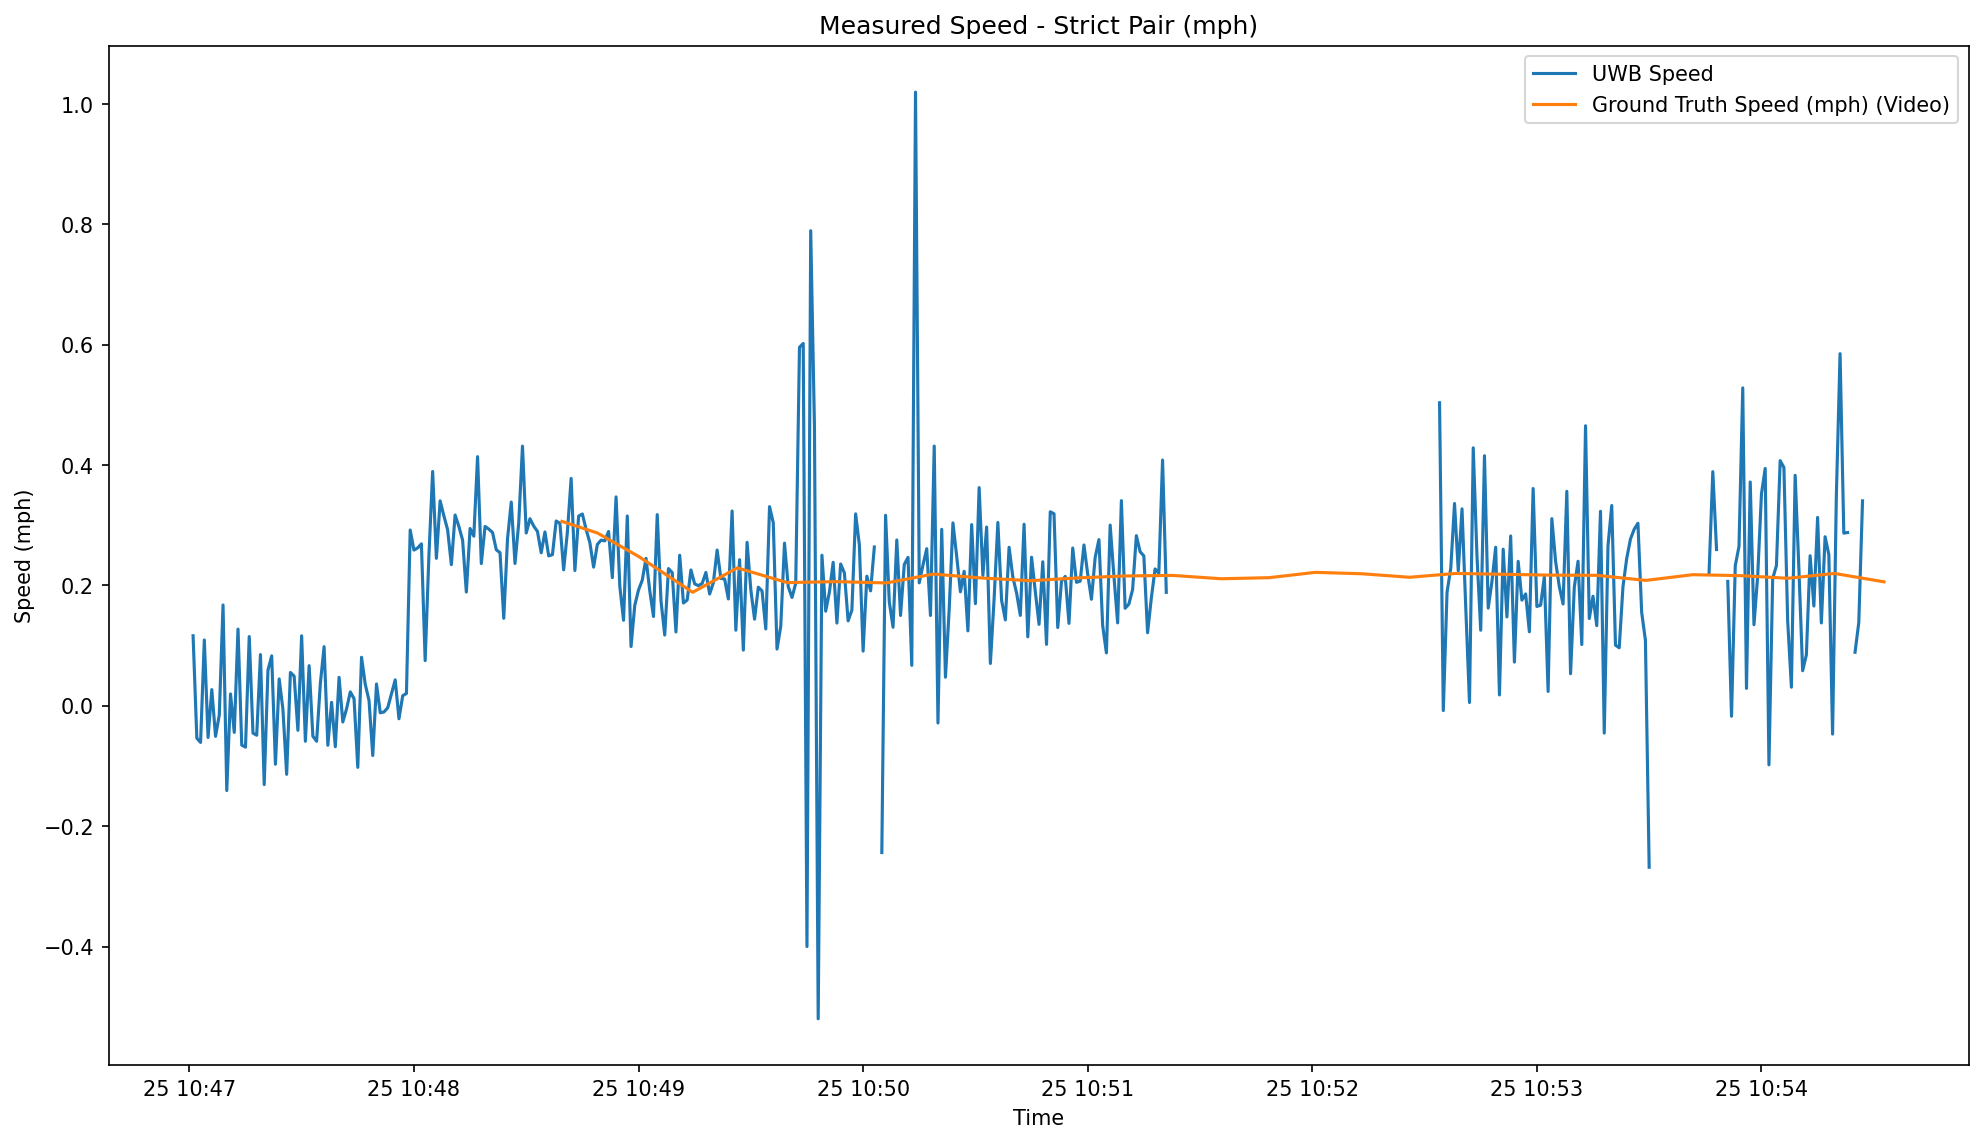

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-10-55-51-moving-v2-1-east-reset\Integrated_ABAB_COMBO-2021-05-25-10-55-51.csv


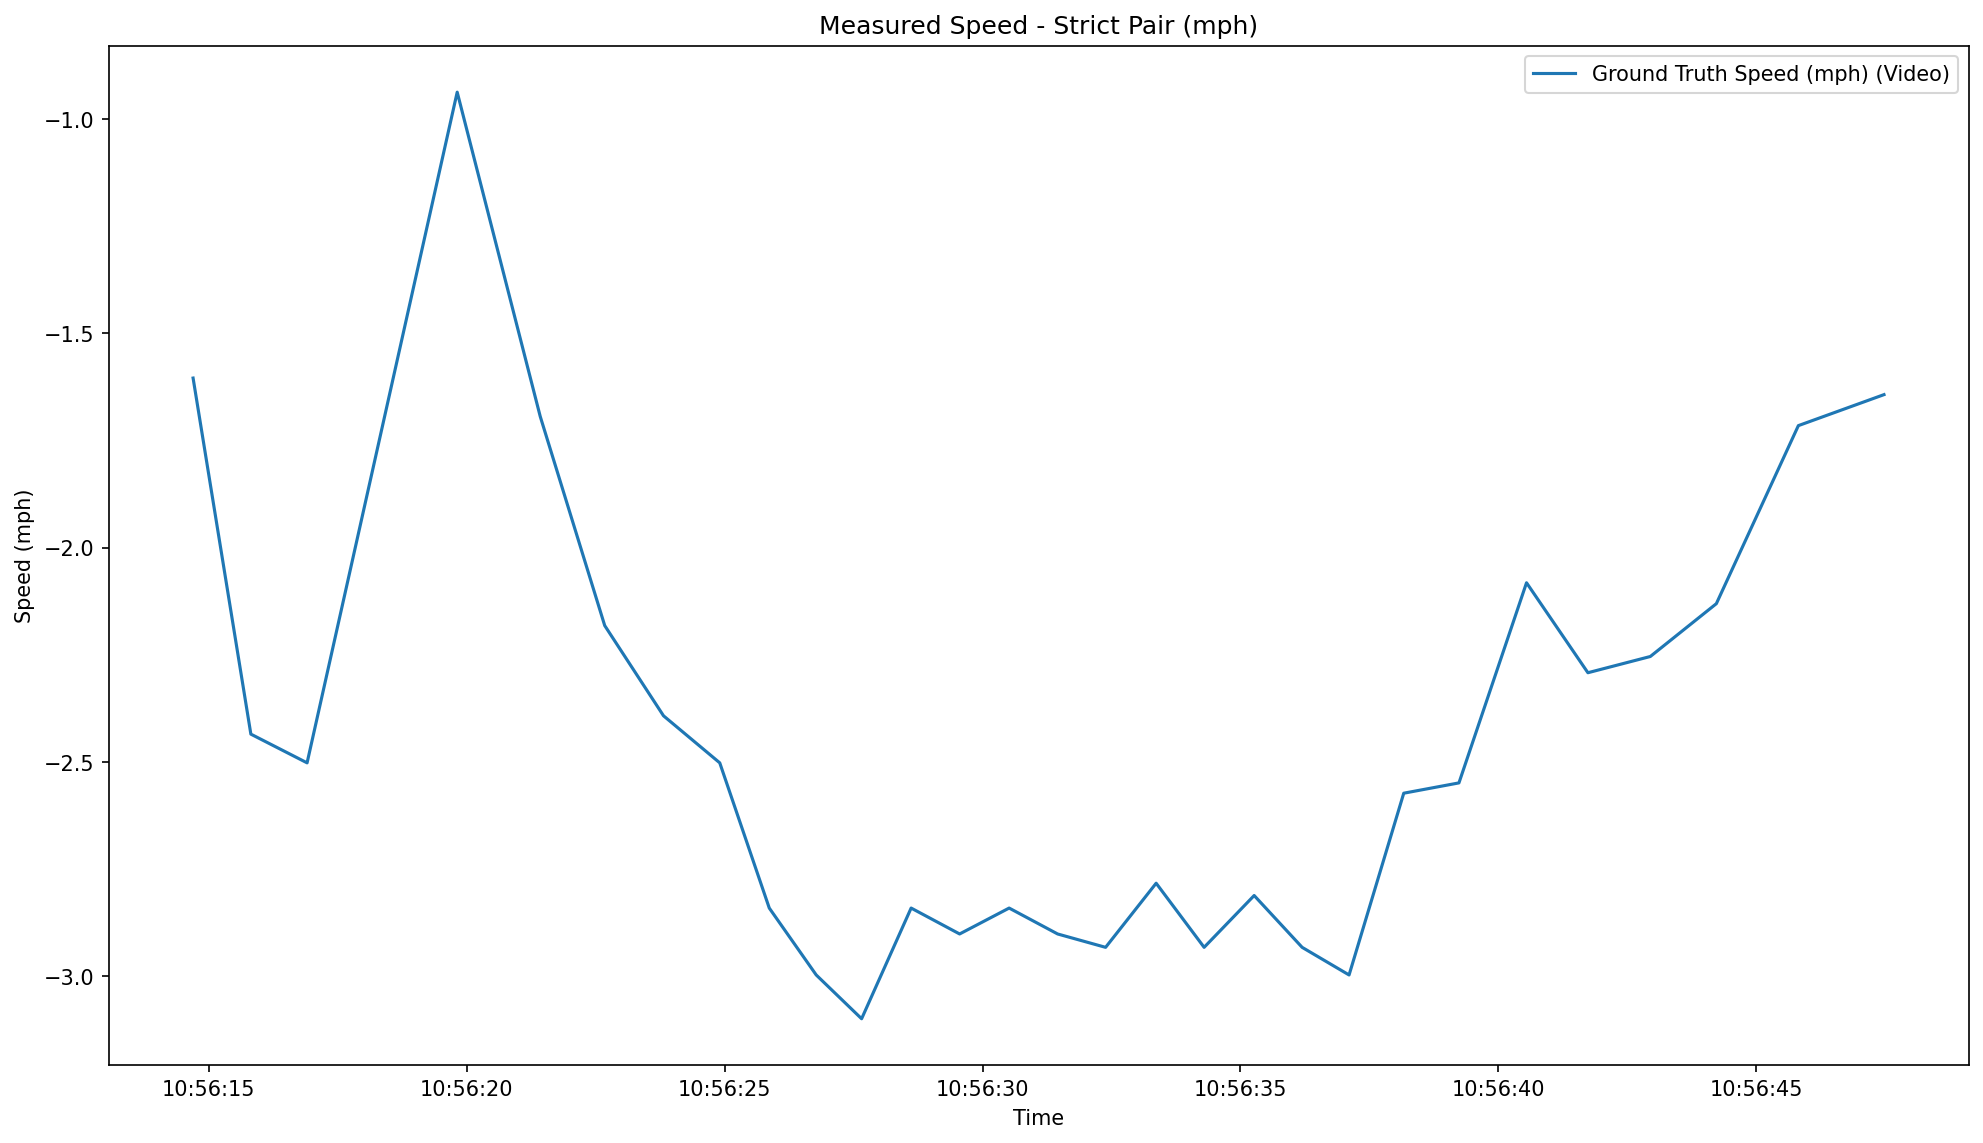

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-11-00-35-moving-v2-2-west-3mph\Integrated_ABAB_COMBO-2021-05-25-11-00-35.csv


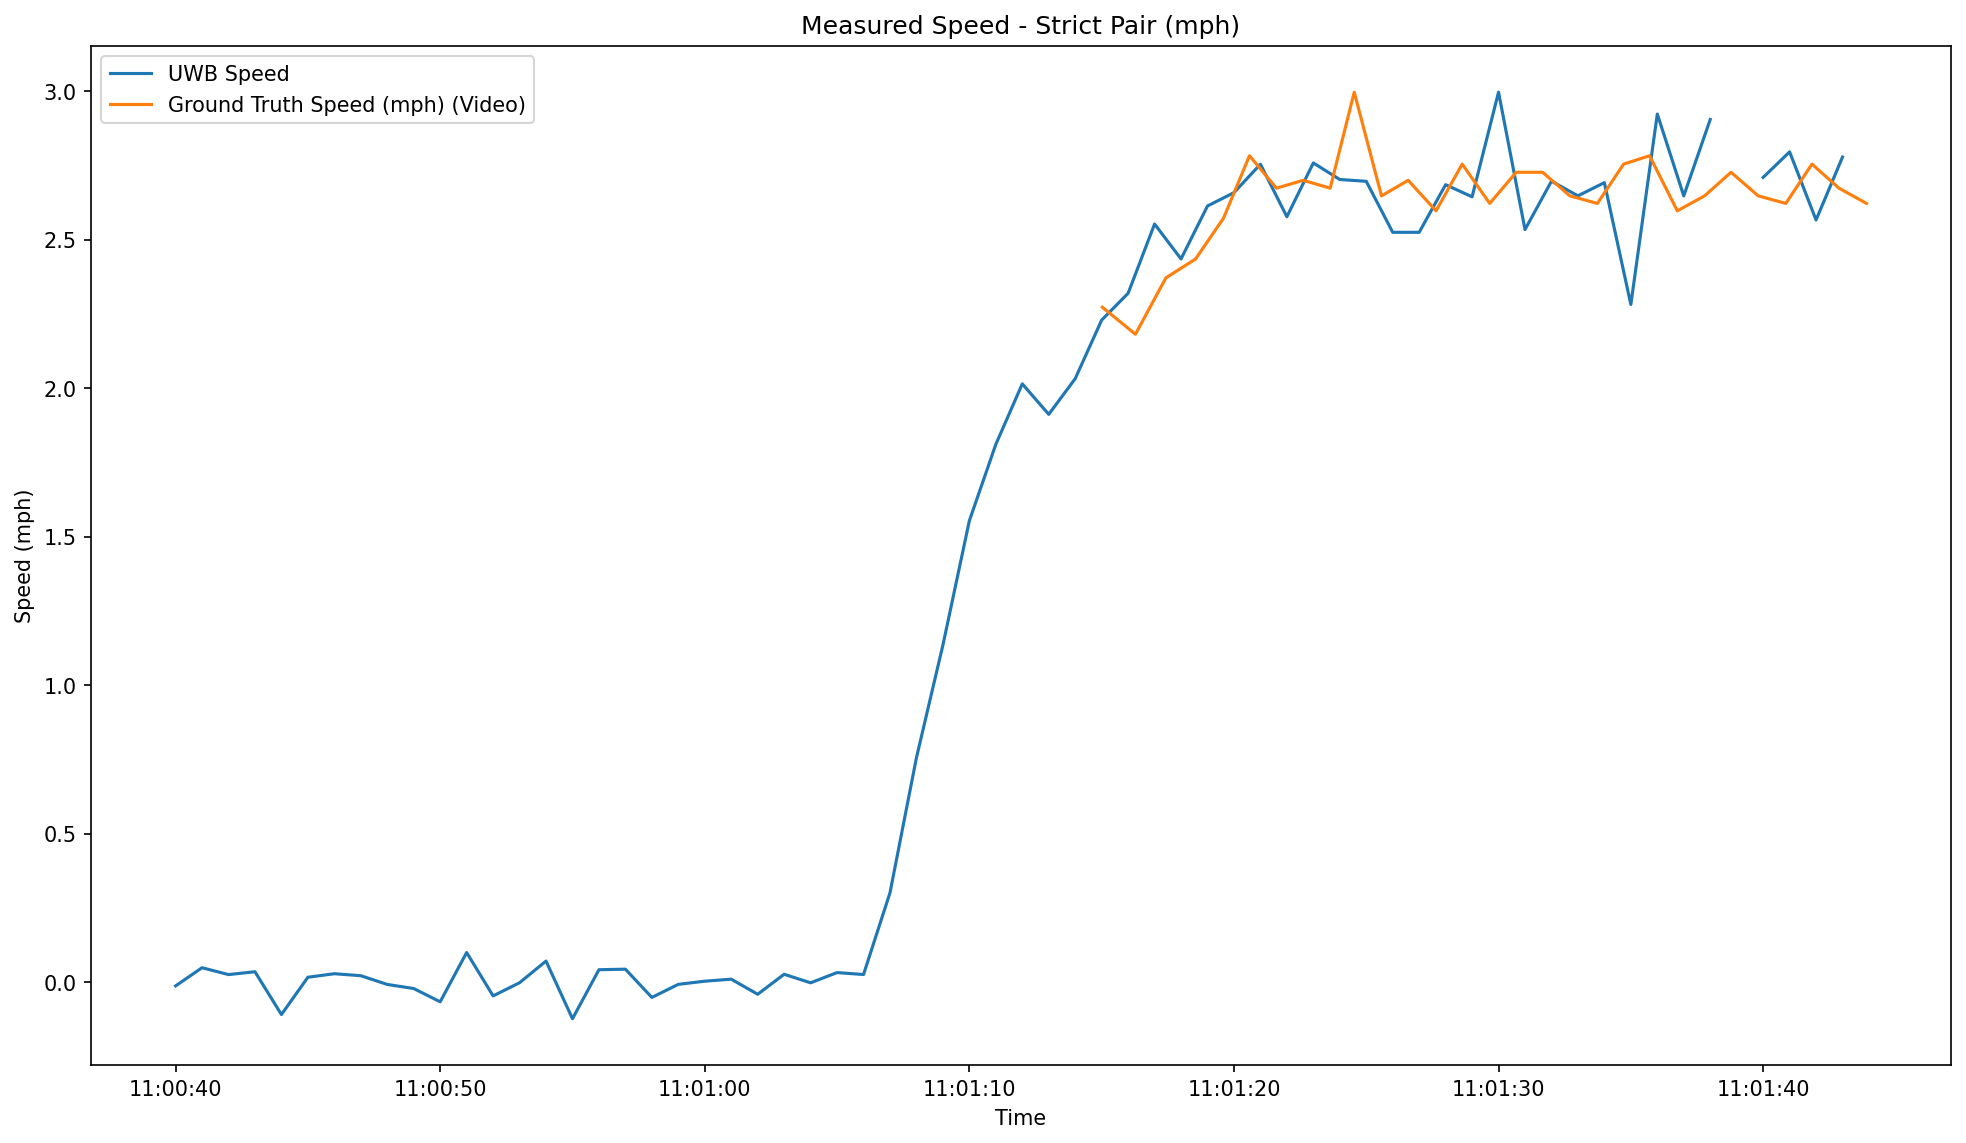

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-11-02-33-moving-v2-2-east-reset\Integrated_ABAB_COMBO-2021-05-25-11-02-33.csv


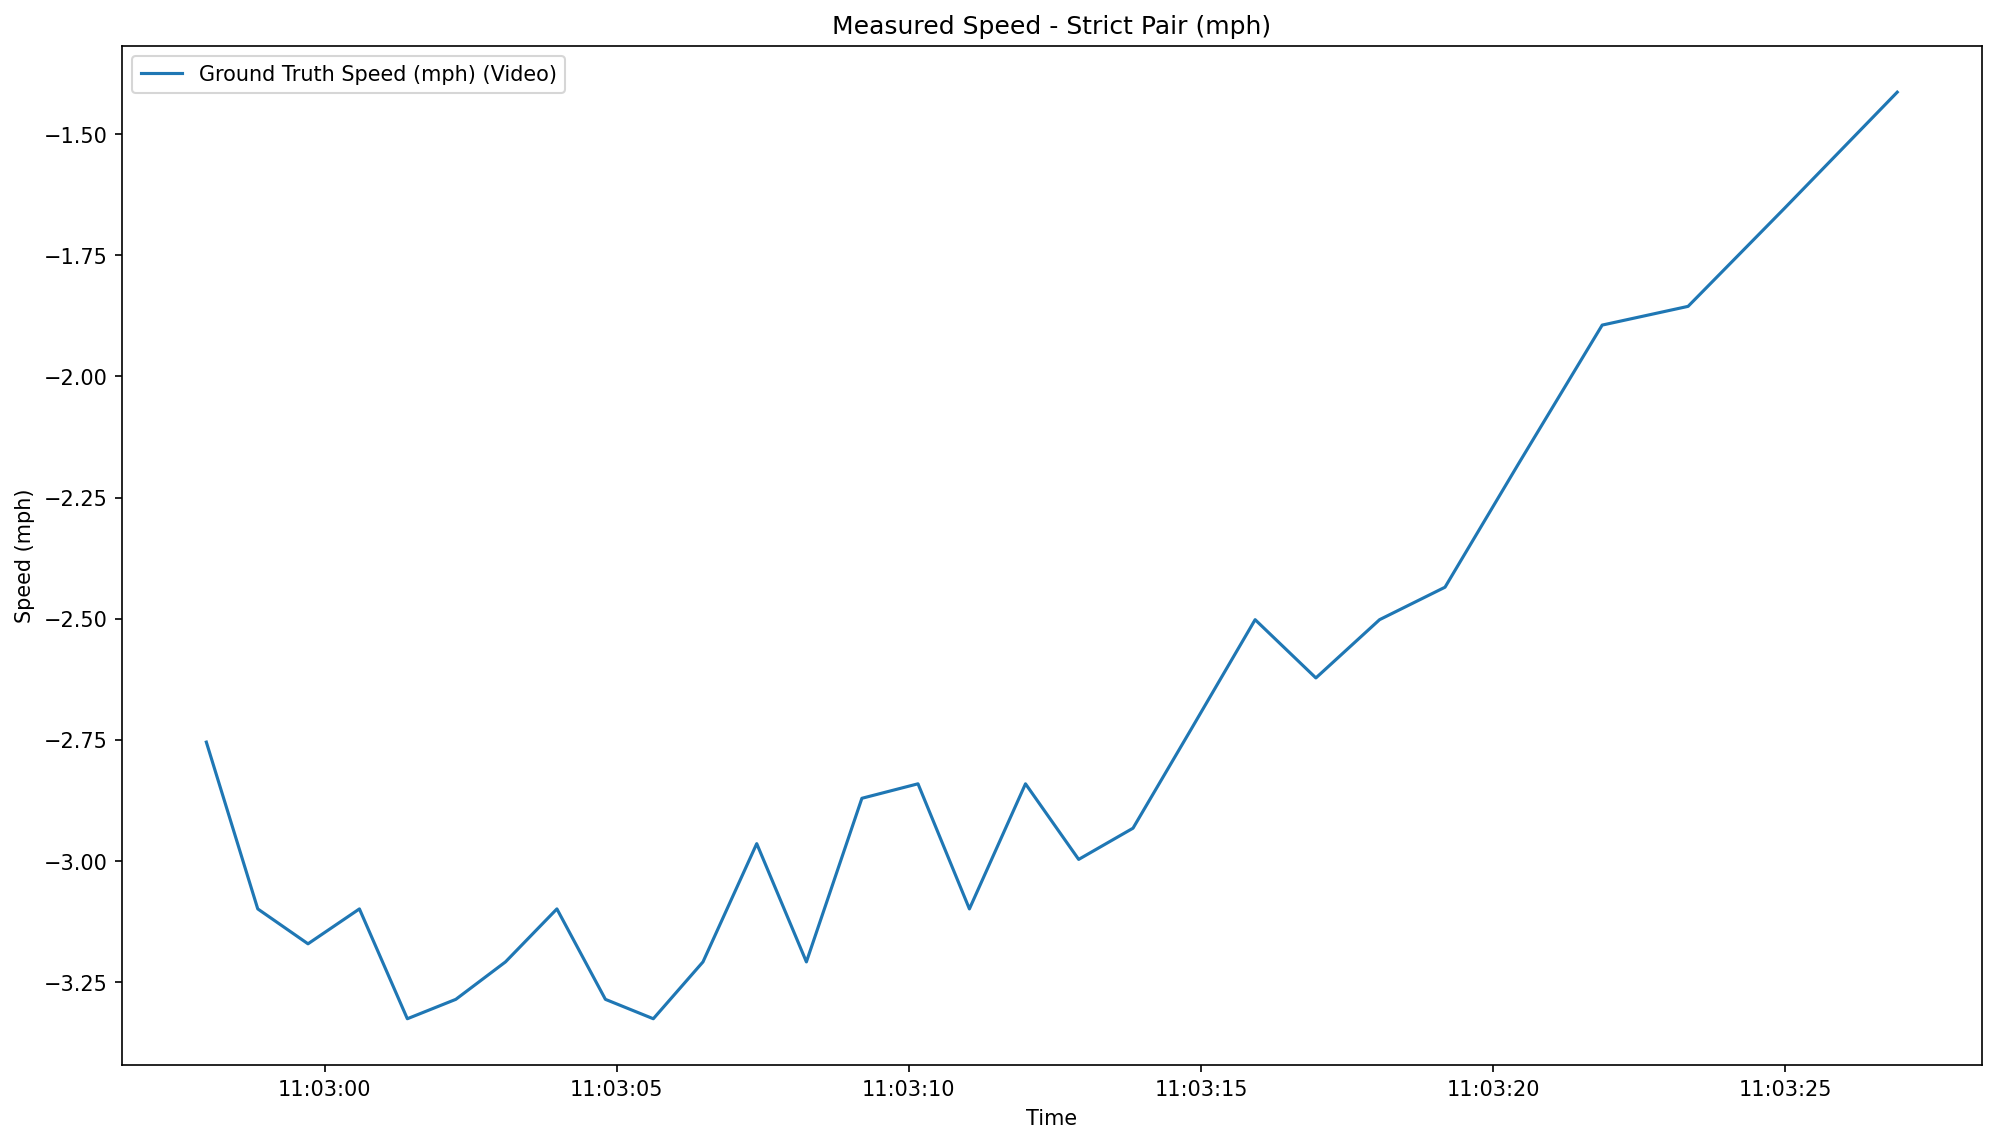

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-11-06-29-moving-v2-3-west-5mph\Integrated_ABAB_COMBO-2021-05-25-11-06-29.csv


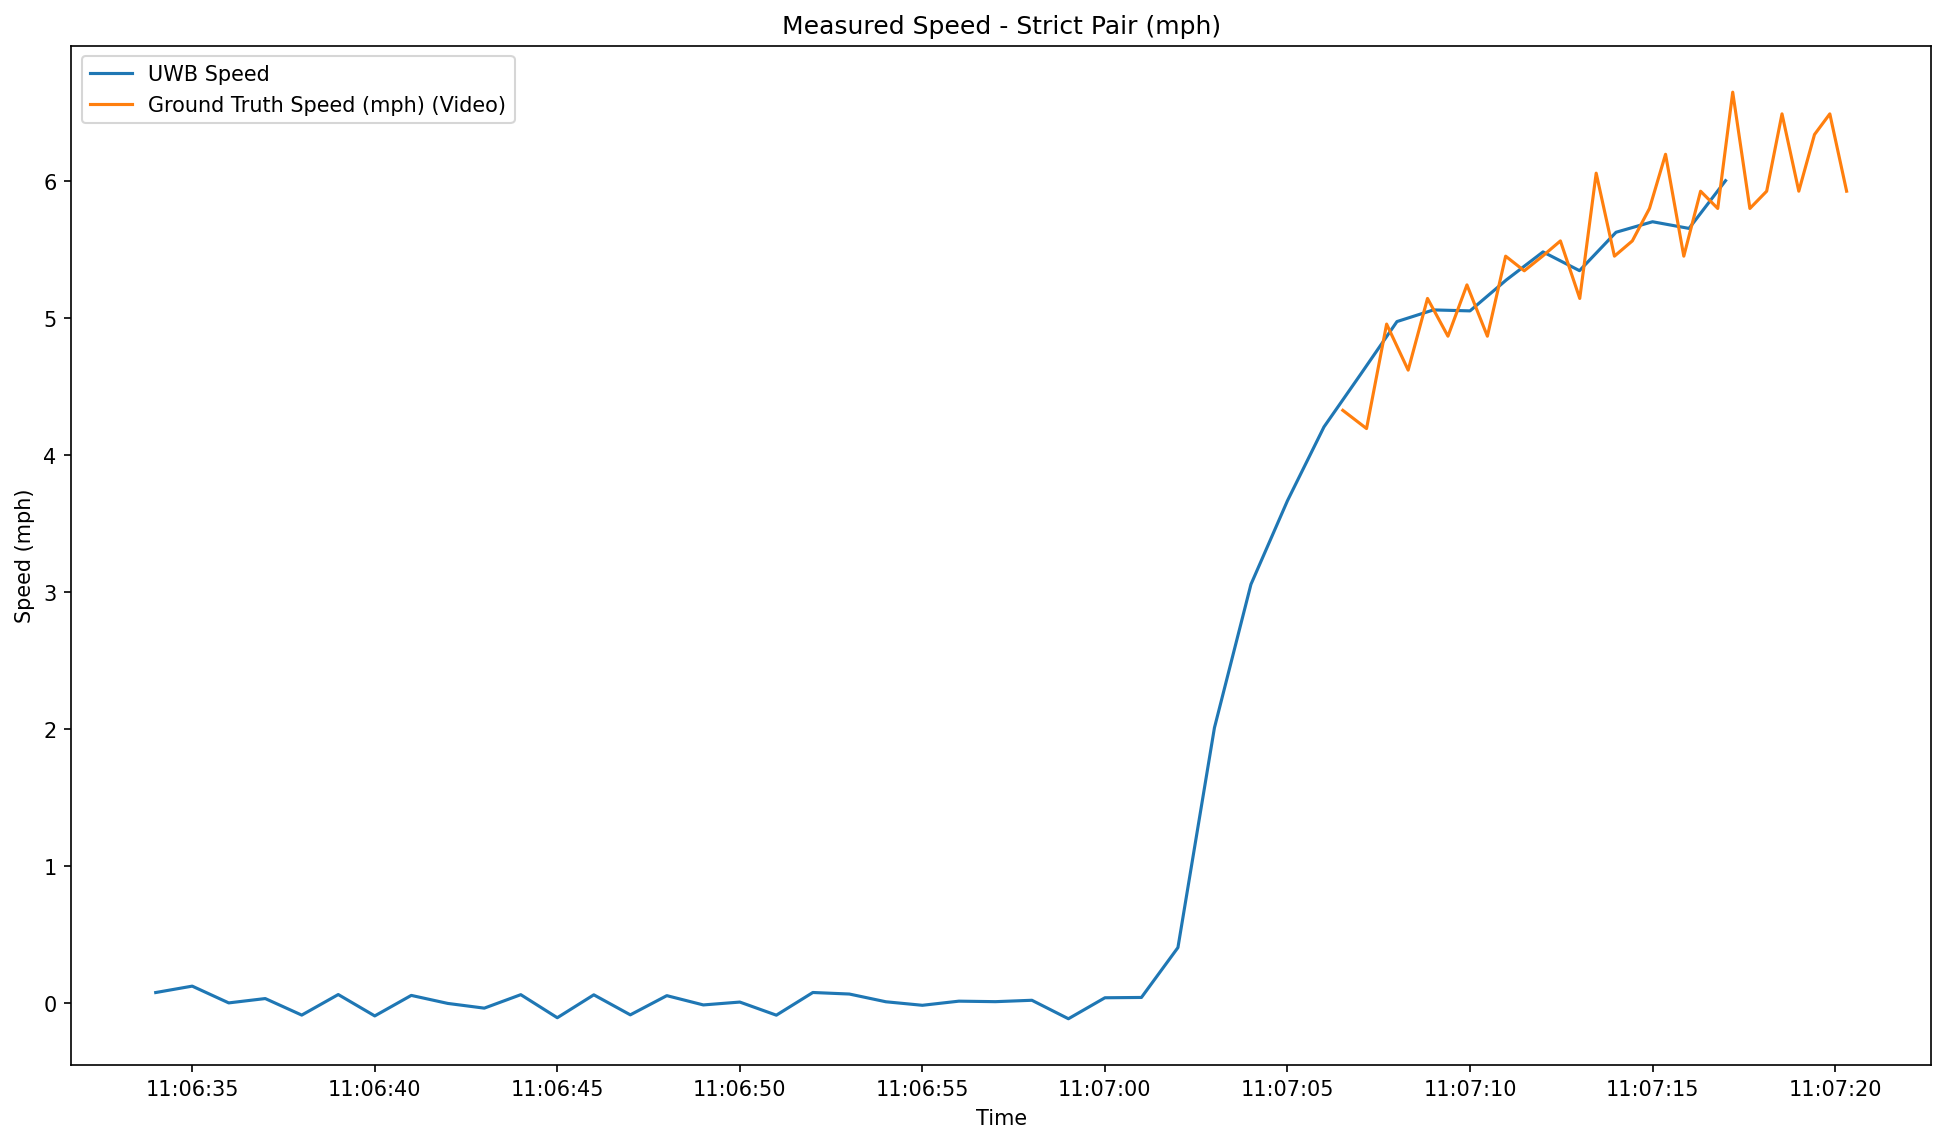

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-11-09-46-moving-v2-3-east-reset\Integrated_ABAB_COMBO-2021-05-25-11-09-46.csv


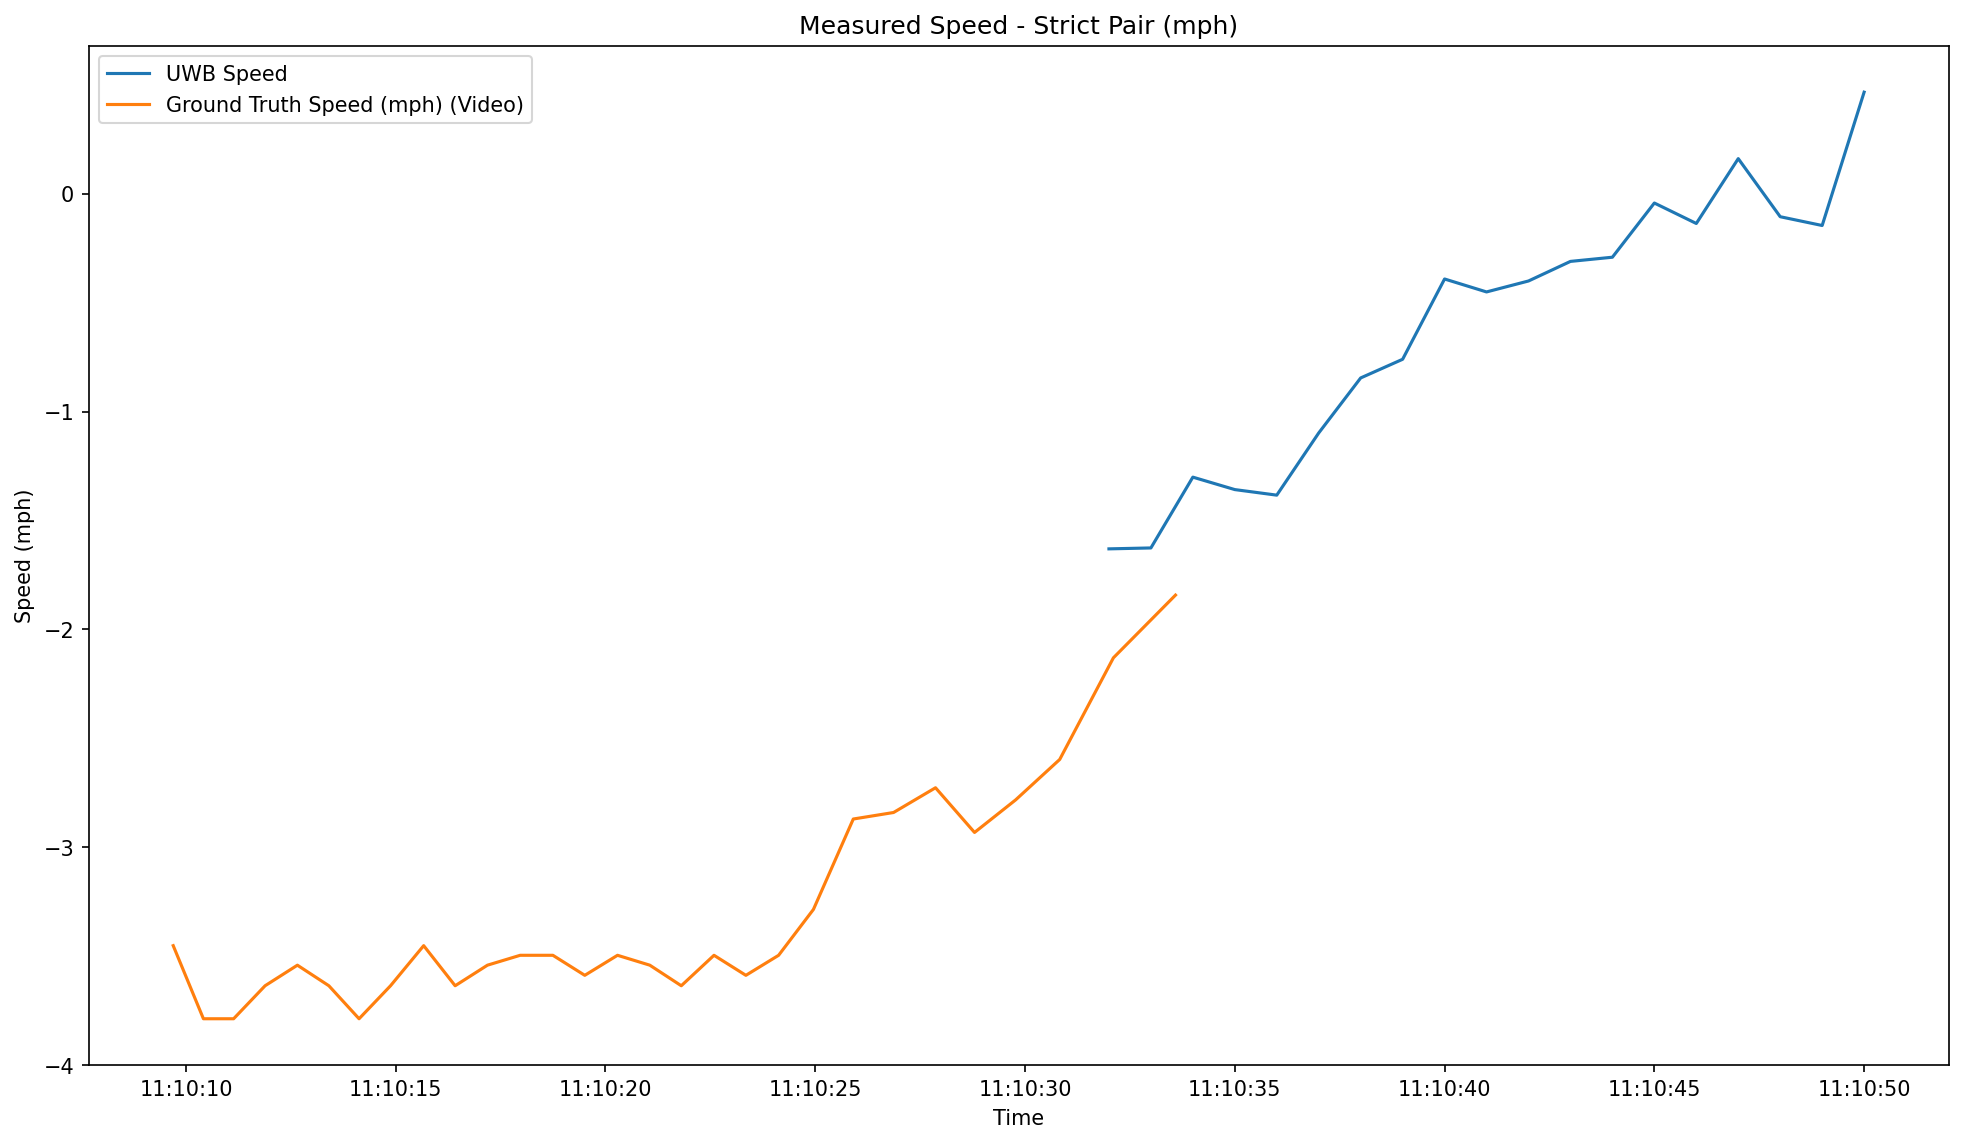

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-11-13-08-moving-v2-4-west-12mph\Integrated_ABAB_COMBO-2021-05-25-11-13-08.csv


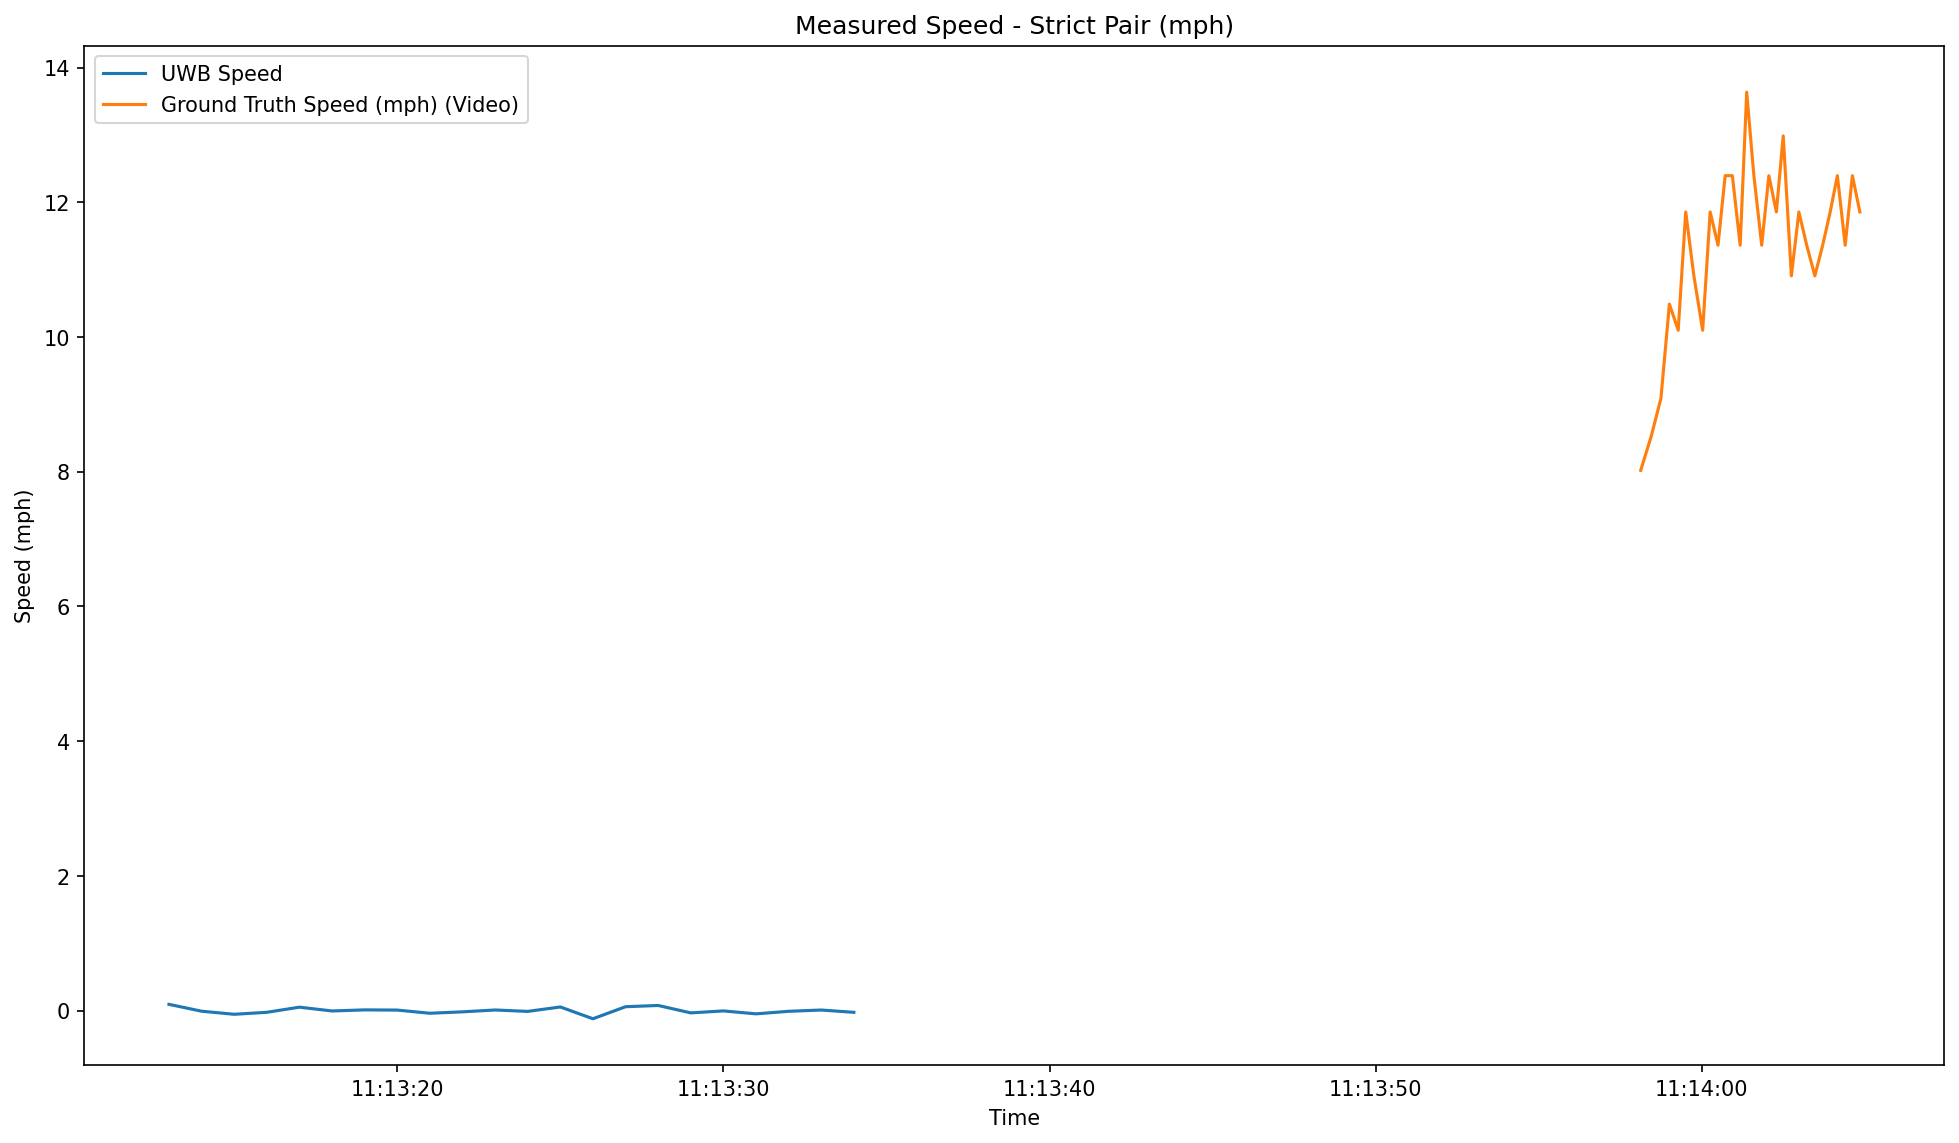

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-11-15-00-moving-v2-4-east-reset\Integrated_ABAB_COMBO-2021-05-25-11-15-00.csv


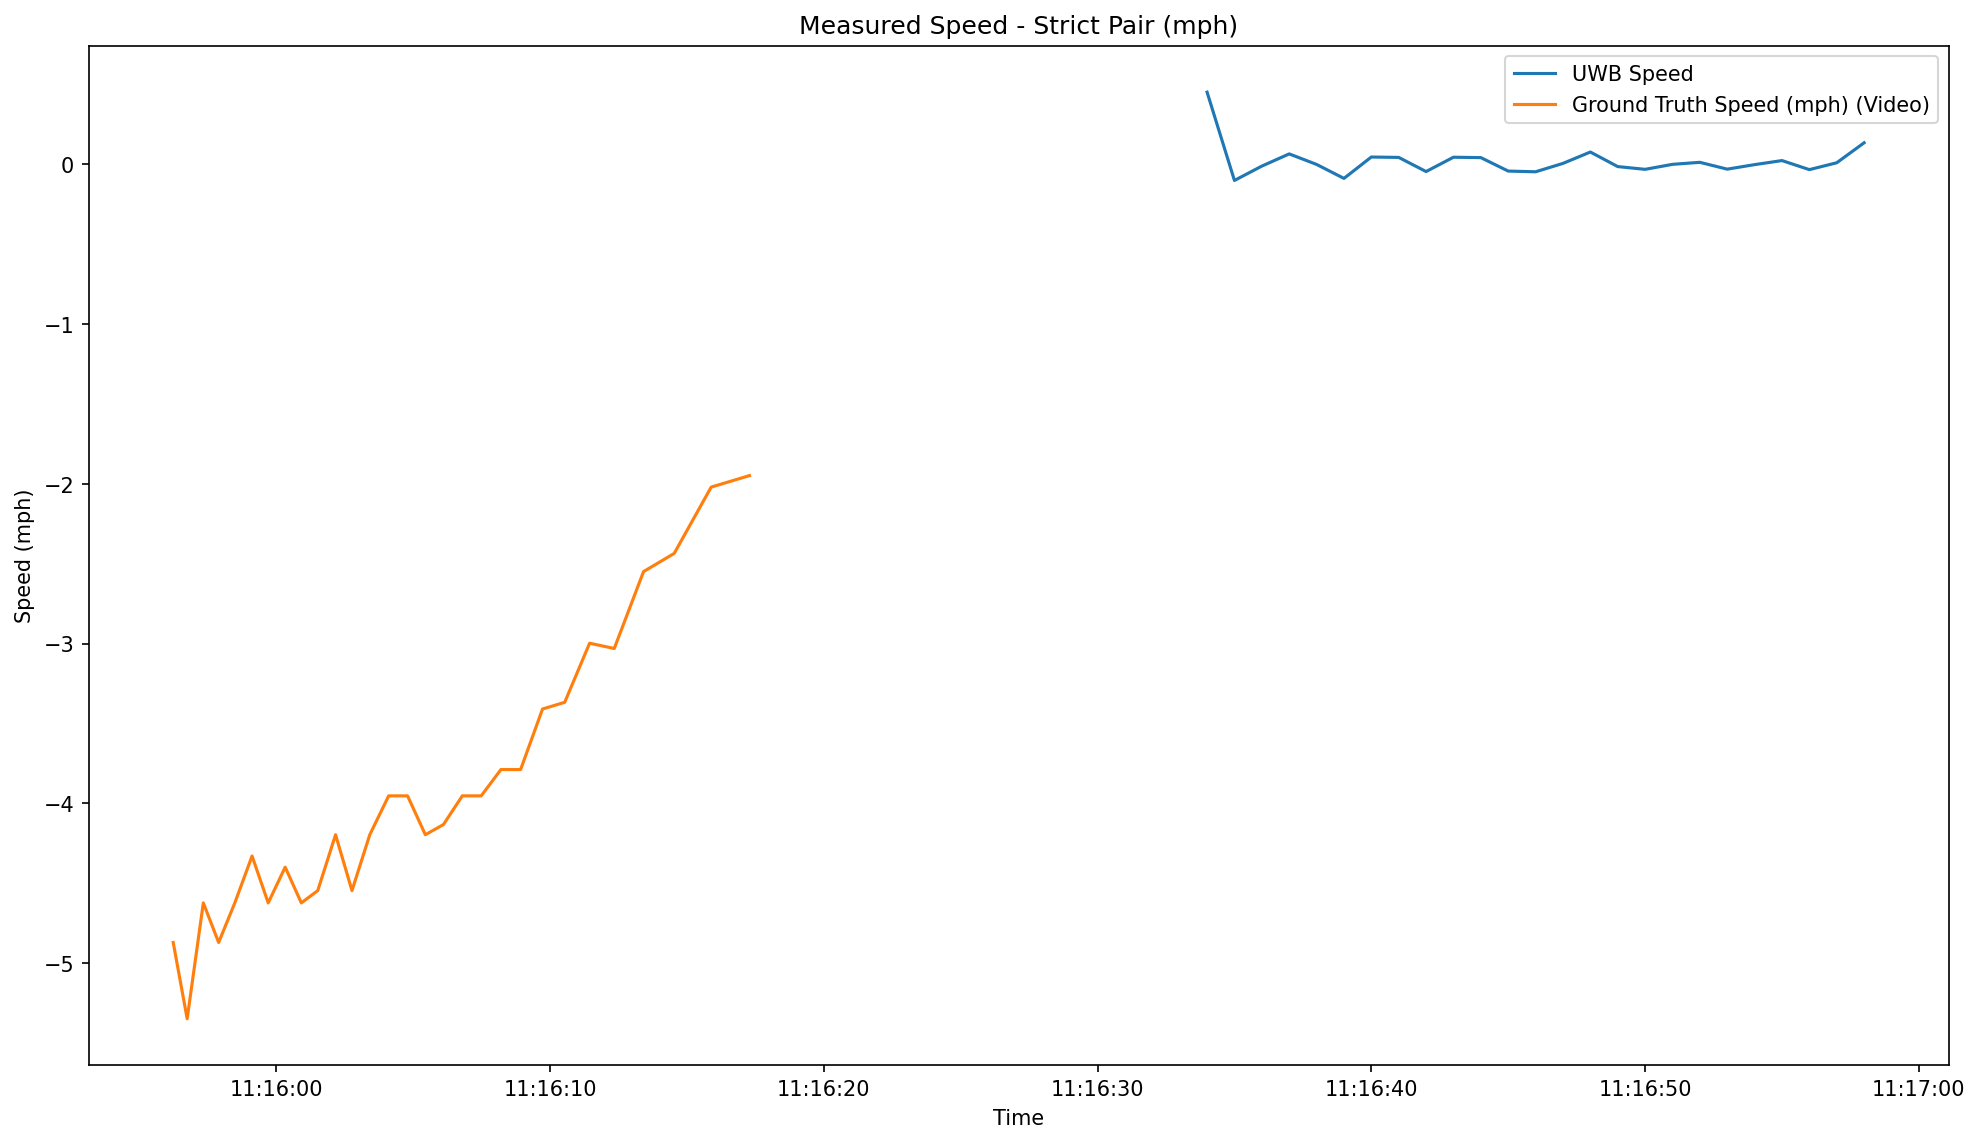

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-11-19-48-moving-v2-5-west-12mph\Integrated_ABAB_COMBO-2021-05-25-11-19-48.csv


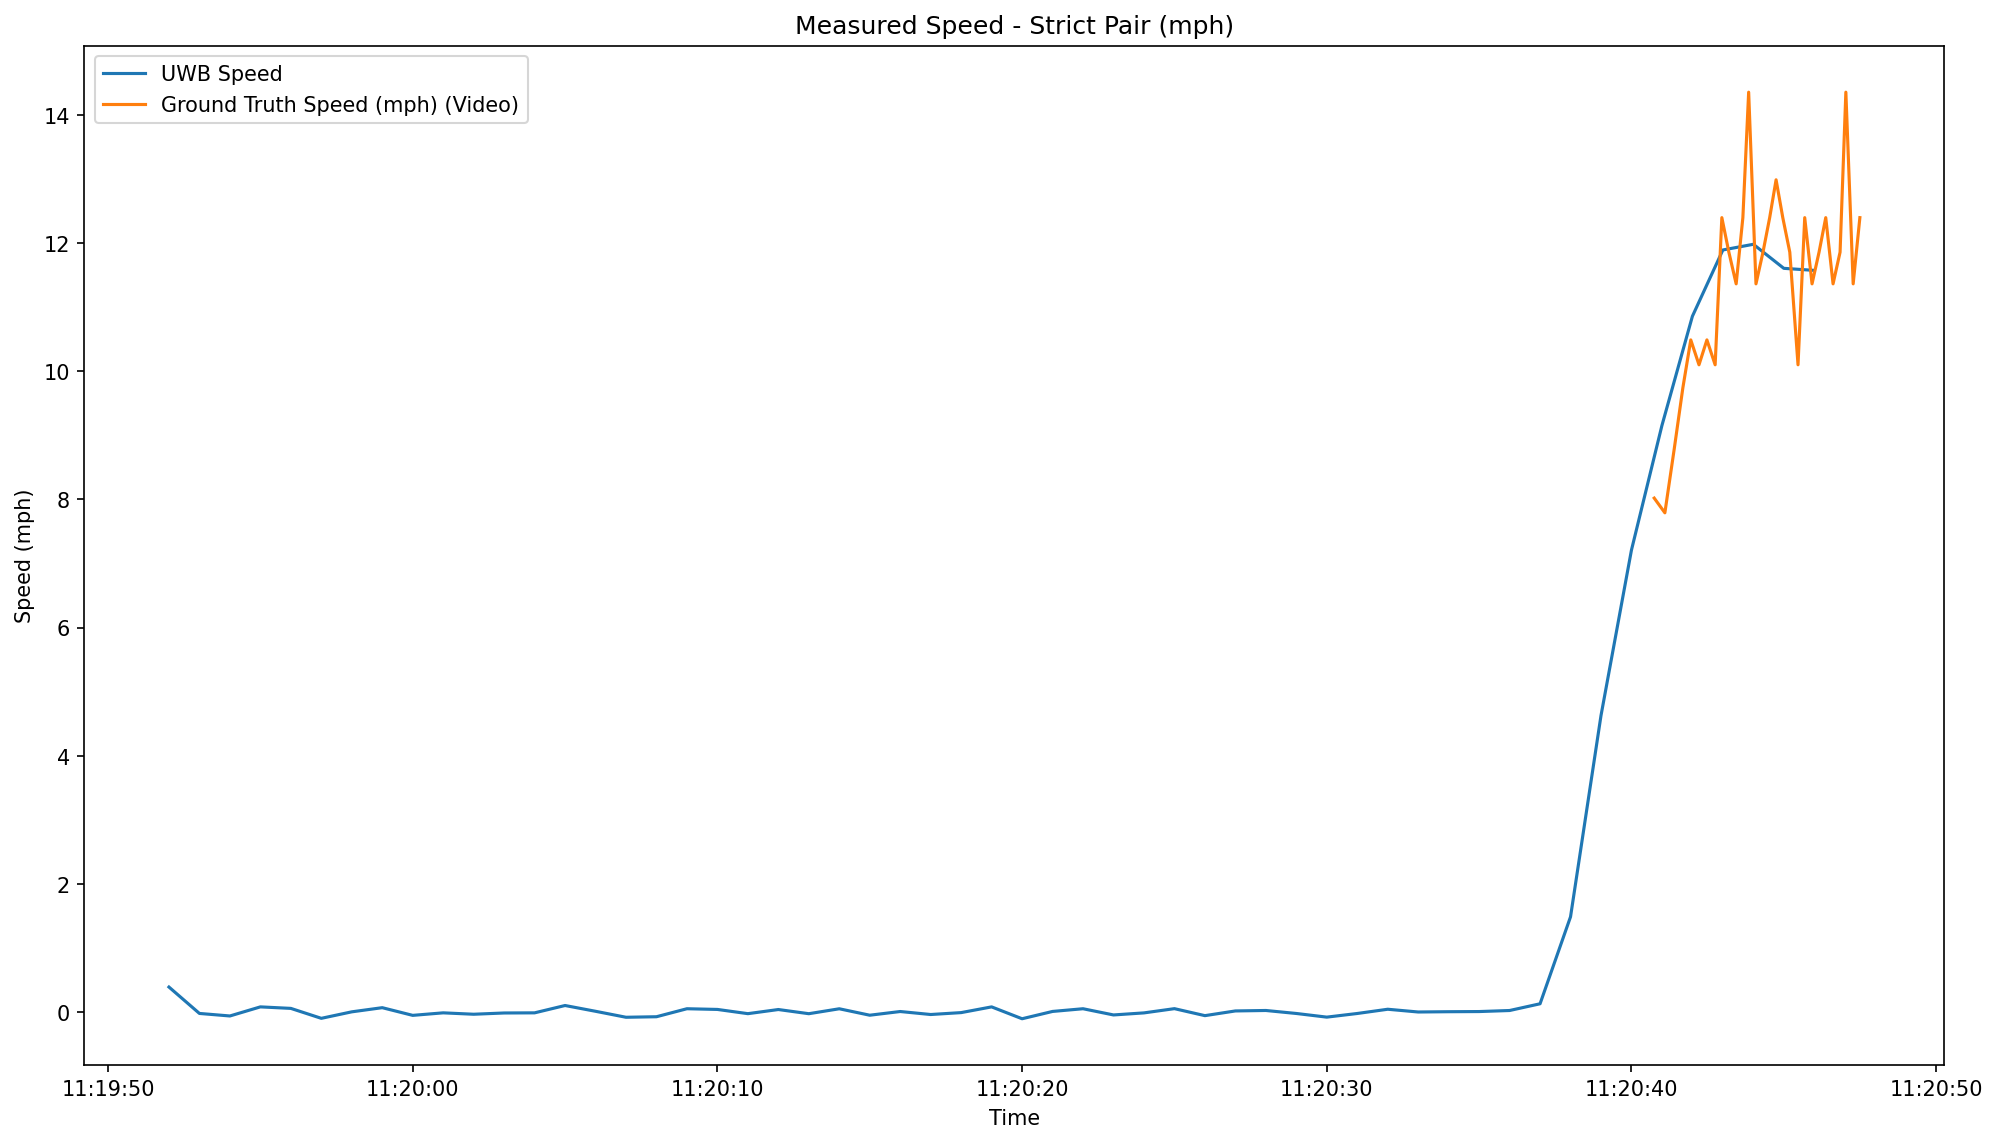

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-11-21-44-moving-v2-5-east-reset\Integrated_ABAB_COMBO-2021-05-25-11-21-44.csv


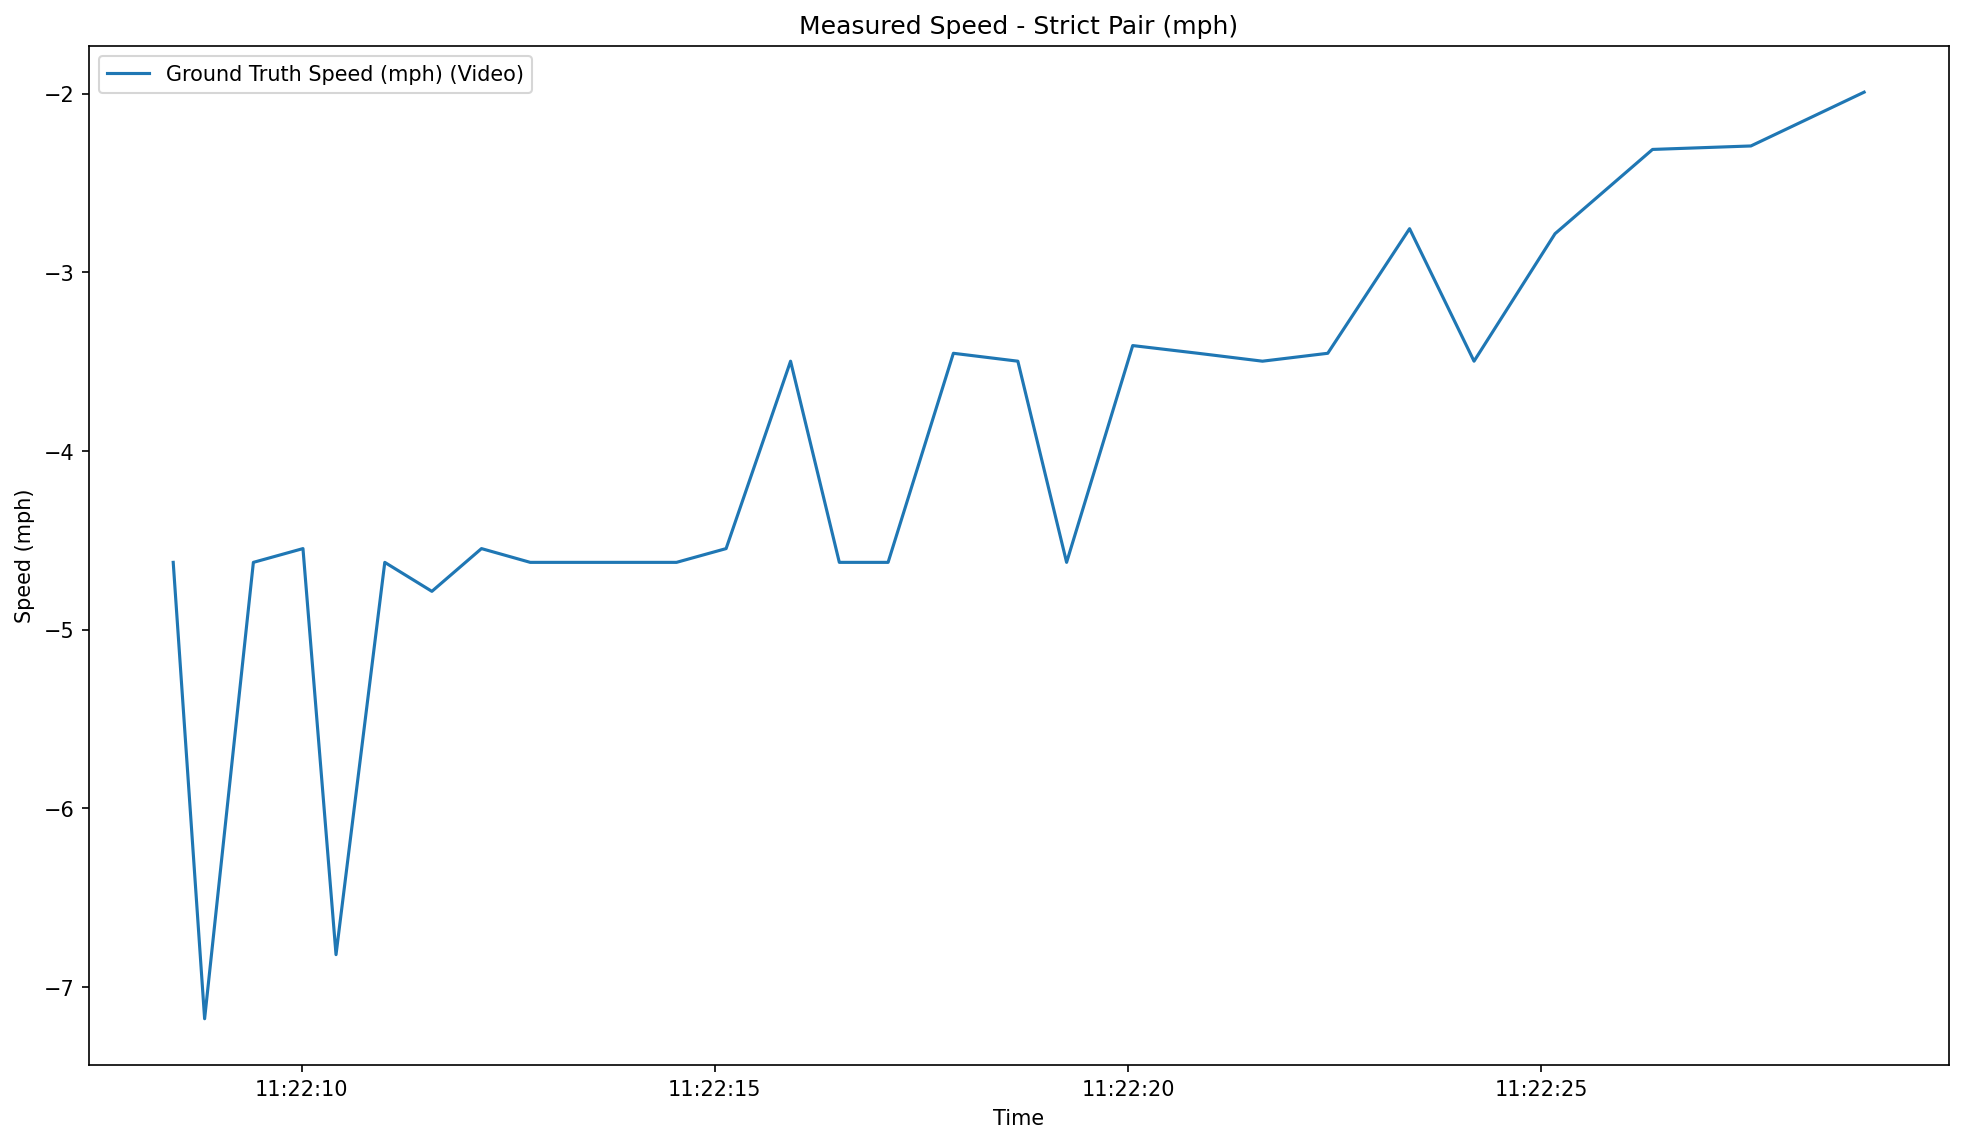

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-11-24-00-moving-v2-6-west-fullspeed\Integrated_ABAB_COMBO-2021-05-25-11-24-00.csv


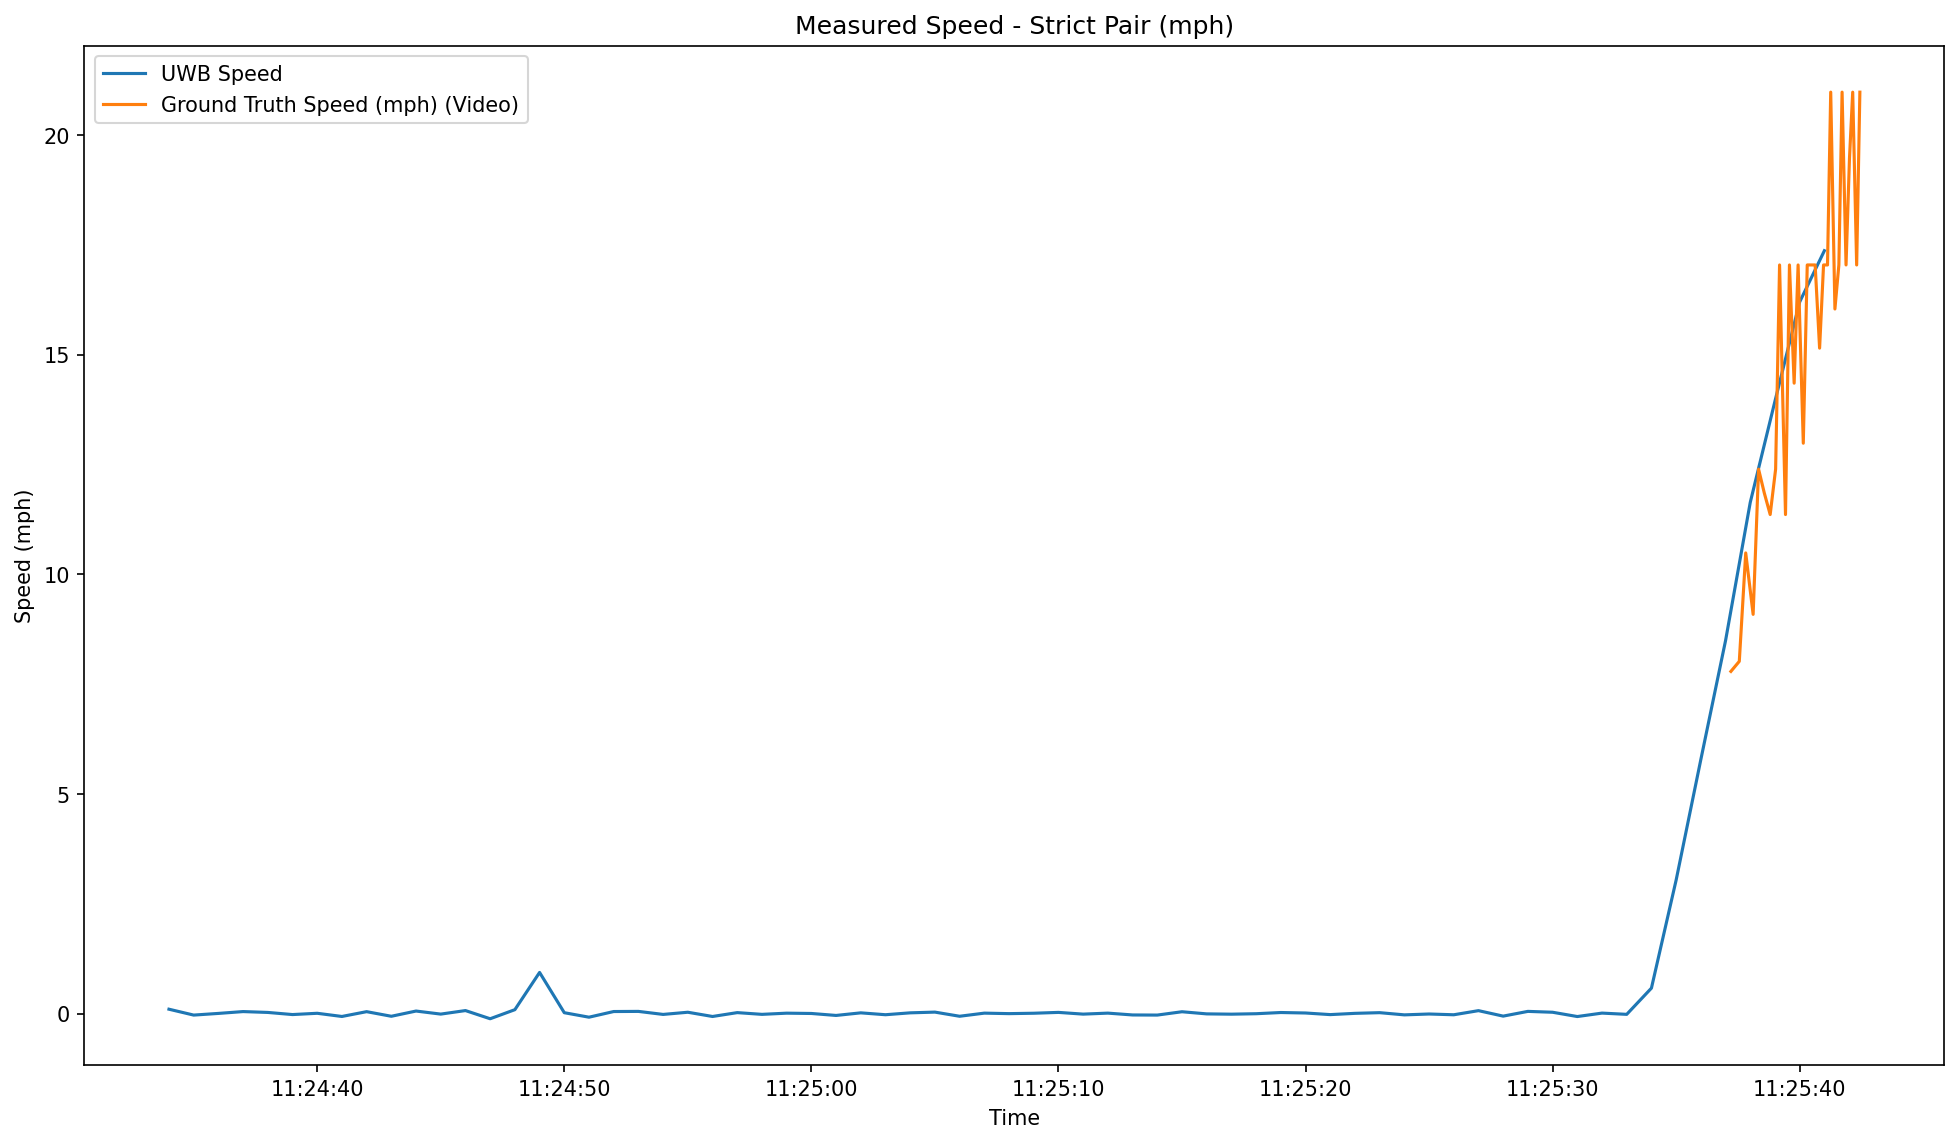

C:/Users/wangz/OneDrive/University_RU/NSUWB/Moving Test 1 (V2V)\V2-THINKPADP52-BallastRegulator-Moving-1\2021-05-25-11-26-40-moving-v2-6-east-reset\Integrated_ABAB_COMBO-2021-05-25-11-26-40.csv


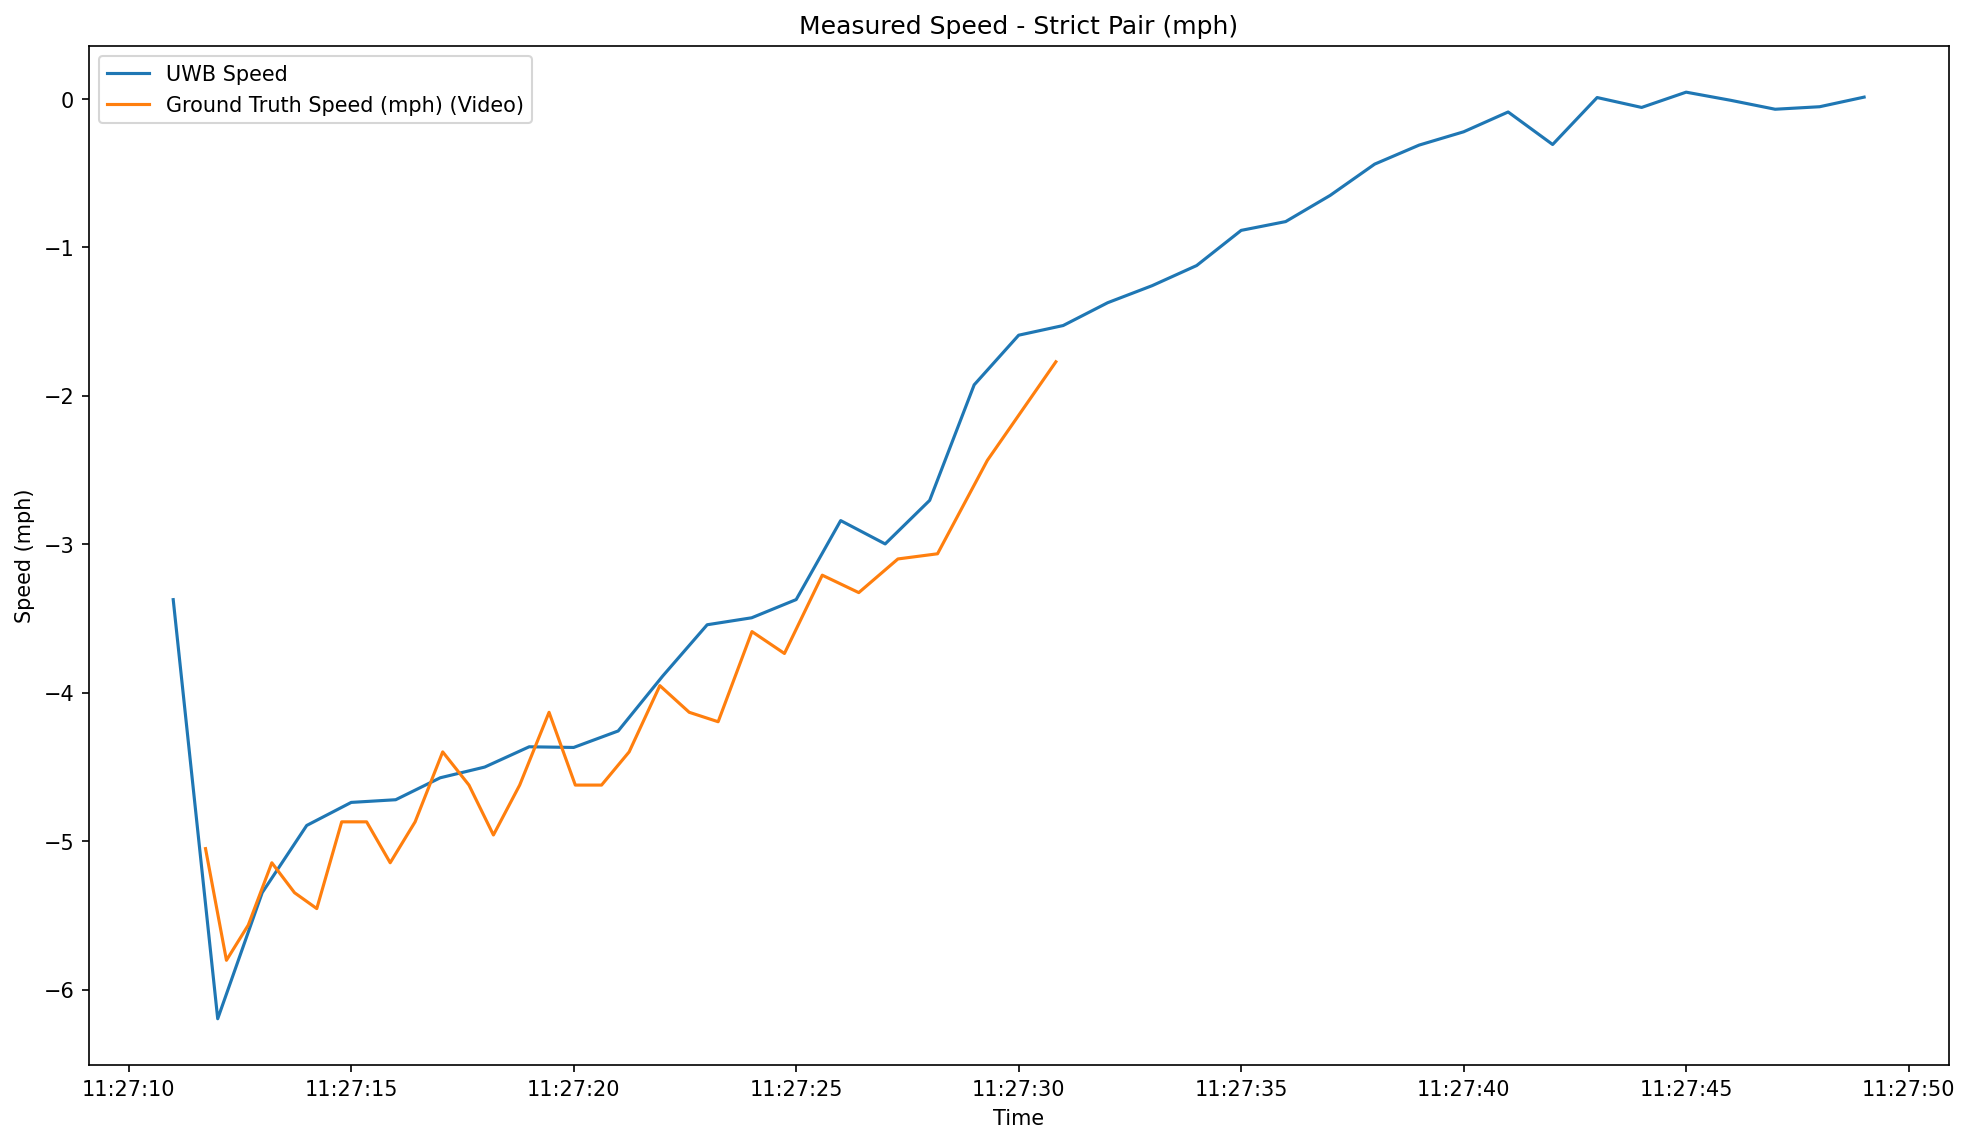

In [154]:
test_file_list, ground_truth_list = post_process_get_moving_test_data_and_timestamp(ROOT_DIR, "Moving Test 1 (V2V)", "V2", CALIBRATED_CAM_TO_V2B)
assert(len(test_file_list) == len(ground_truth_list))
static_veh, moving_veh = 1, 2
added_spd_dfs = []
for i in range(len(test_file_list)):
    test_file, ground_truth = test_file_list[i], ground_truth_list[i]
    if "data-A-user-processed_log" in test_file and os.path.basename(test_file).startswith("2021"):
        continue
    _test_csv_base = "PostProcessed_" + os.path.splitext(os.path.basename(test_file))[0] + ".csv"
    _integ_csv_base = "Integrated_ABAB_COMBO-" + _test_csv_base.split("PostProcessed_")[1].split("-data-")[0] + ".csv"
    _integ_csv_dir = os.path.join(os.path.dirname(test_file), _integ_csv_base)
    
    df = pd.read_csv(_integ_csv_dir, parse_dates=["Datetime Normalized"], index_col=["Datetime Normalized"])
    df_static_veh = remove_distance_outlier(df[df['Initiating Vehicle'] == static_veh], "Correction Distance (mm)") 
    df_moving_veh = remove_distance_outlier(df[df['Initiating Vehicle'] == moving_veh], "Correction Distance (mm)")
    
    df_static_veh.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True, ignore_index=True)
    df_moving_veh.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True, ignore_index=True)
    
    # Calculate Ground Truth Instant Speed
    dist_diff = ground_truth["Camera Dist to Static Veh (CPLR, mm)"].diff().fillna(0.)
    time_diff = ground_truth["Time UNIX Norm (s)"].diff().fillna(0.)
    ground_truth["Instant Speed by Marker (mph)"] = (dist_diff / time_diff) * 0.00223694
    
    # Calculate UWB Measured Instant Speed by Vehicle's Master with Each Slave to Range
    slices_uwb_spd_strict_pair = []
    figure = plt.figure(figsize=(16, 9), dpi=150)
    for master_id in df['Initiating Master'].unique():
        for slave_id in df['Reporting Slave'].unique():
            sliced_by_designated_slave = df[(df['Reporting Slave'] == slave_id) & (df['Initiating Master'] == master_id)].copy()
            _dist_diff = df["Correction Distance (mm)"].diff().fillna(0.)
            _time_diff = df["Timestamp Norm (s)"].diff().fillna(0.)
            spd_mph = (_dist_diff / _time_diff) * 0.00223694
            spd_mph = spd_mph.to_frame('UWB Measured Speed - Strict Pair (mph)')
            sliced_by_designated_slave = pd.concat([sliced_by_designated_slave, spd_mph])
            slices_uwb_spd_strict_pair.append(sliced_by_designated_slave)
    print(_integ_csv_dir)
    added_spd_uwb_strict_pair = pd.DataFrame()
    ax = figure.add_subplot()
    for _df in slices_uwb_spd_strict_pair:
        added_spd_uwb_strict_pair = pd.concat([added_spd_uwb_strict_pair, _df])
        added_spd_uwb_strict_pair.sort_values(['Initiating Vehicle', 'Initiating Master', 'Reporting Slave', 'Timestamp Norm (s)'], ascending=[True, True, True, True])
    if not added_spd_uwb_strict_pair.empty:
        _ = added_spd_uwb_strict_pair.resample(rule="1S").mean()
        ax.plot(_.index, _["UWB Measured Speed - Strict Pair (mph)"], label="UWB Speed")
        added_spd_dfs.append(added_spd_uwb_strict_pair)
    if ground_truth is not None:
        ax.plot(pd.to_datetime(ground_truth["Time UNIX Norm (s)"],unit='s'), ground_truth["Instant Speed by Marker (mph)"], label="Ground Truth Speed (mph) (Video)")
    ax.set_title("Measured Speed - Strict Pair (mph)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Speed (mph)")
    ax.legend()
    plt.show()

In [79]:
master_info={'x_master': 290, 'y_master': -1190, 'z_master': 2820, 'vehicle_length_master': 15470, 'id_assoc': 1, 'side_master': 2, 'master_id': '0C1A'}
slave={'slave_id': '1912', 'x_slave': 2420, 'y_slave': 1460, 'z_slave': 1870, 'vehicle_length_slave': 12140, 'id_assoc': 2, 'side_slave': 1, 'dist_to': 5508}

In [83]:
same_track_side_longitudinal_dist(master_info, slave) \
                                    - master_info["x_master"] - slave['x_slave']

2708

In [76]:
side_to_side_dist

2708

In [4]:
arrays = [['Falcon', 'Falcon', 'Parrot', 'Parrot'],
          ['Captive', 'Wild', 'Captive', 'Wild']]
index = pd.MultiIndex.from_arrays(arrays, names=('Animal', 'Type'))
df = pd.DataFrame({'Max Speed': [390., 350., 30., 20.]},
                  index=index)

In [6]:
df.groupby(level=0)

In [11]:
df = pd.DataFrame({'Animal': ['Falcon', 'Falcon',
                              'Parrot', 'Parrot'],
                   'Max Speed': [380., 370., 24., 26.]})
df

,Animal,Max Speed
0,Falcon,380.0
1,Falcon,370.0
2,Parrot,24.0
3,Parrot,26.0


In [9]:
df.groupby(["Animal"])

In [10]:
df

,Animal,Max Speed
0,Falcon,380.0
1,Falcon,370.0
2,Parrot,24.0
3,Parrot,26.0
